# SofaScore Ratings Analysis

Compare average SofaScore ratings between Montenegrin and non-Montenegrin players in the 1. CFL 2025/26 season.

In [31]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as path_effects
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image

# ─── Path Configuration ──────────────────────────────────────────
LEAGUE = 'cg'  # 'cg' = Montenegro 1. CFL | 'srb' = Serbian SuperLiga

DATA_DIR       = Path('..') / 'data' / 'processed' / LEAGUE
FIGURES_DIR    = Path('..') / 'outputs' / LEAGUE / 'figures'
FINAL_DIR      = Path('..') / 'outputs' / LEAGUE / 'final_posts'
TEAM_LOGOS_DIR = DATA_DIR / 'team_logos'
PLAYER_PHOTOS  = DATA_DIR / 'player_photos'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ─── Visual Constants ────────────────────────────────────────
BG_COLOR   = '#0a0a0a'
GOLD       = '#d4af37'
TEXT_WHITE = '#FFFFFF'
TEXT_GREY  = '#A0A0A0'
RED        = '#e74c3c'
BLUE       = '#3498db'
GREEN      = '#2ecc71'
ORANGE     = '#f39c12'

MNE_COLOR  = '#e74c3c'   # Montenegrin players
FOR_COLOR  = '#3498db'   # Foreign players

In [32]:
# ─── Load Data ───────────────────────────────────────────────
players = pd.read_csv(DATA_DIR / 'players_metadata.csv')
season  = pd.read_csv(DATA_DIR / 'player_season_statistics.csv')
match_stats = pd.read_csv(DATA_DIR / 'match_player_statistics.csv')

# Quick overview
print(f'Players metadata:  {len(players)} players')
print(f'Season stats:      {len(season)} rows')
print(f'Match-level stats: {len(match_stats)} rows')

print(f'\nCountry distribution (top 10):')
print(season['country_name'].value_counts().head(10).to_string())

print(f'\nAvg rating stats:')
print(season['avg_rating'].describe().to_string())

Players metadata:  329 players
Season stats:      292 rows
Match-level stats: 4974 rows

Country distribution (top 10):
country_name
Montenegro              232
Serbia                   26
Argentina                 6
Bosnia & Herzegovina      5
Japan                     3
Brazil                    2
Greece                    2
Croatia                   2
Kosovo                    2
Senegal                   2

Avg rating stats:
count    285.000000
mean       6.783263
std        0.221706
min        6.200000
25%        6.640000
50%        6.760000
75%        6.920000
max        7.580000


In [33]:
# ─── Classify: Montenegrin vs Foreign ────────────────────────
# Using season stats which already has country_name and avg_rating
# Filter to players with enough minutes for meaningful ratings
MIN_MINUTES = 450  # ~5 full matches

df = season[season['minutes_played'] >= MIN_MINUTES].copy()
df['is_mne'] = df['country_name'] == 'Montenegro'
df['group'] = df['is_mne'].map({True: 'Crnogorci', False: 'Stranci'})

mne = df[df['is_mne']]
foreign = df[~df['is_mne']]

print(f'Players with >= {MIN_MINUTES} min:')
print(f'  Crnogorci:  {len(mne)} players, avg rating: {mne["avg_rating"].mean():.2f}')
print(f'  Stranci:    {len(foreign)} players, avg rating: {foreign["avg_rating"].mean():.2f}')
print(f'  Difference: {foreign["avg_rating"].mean() - mne["avg_rating"].mean():+.2f} in favour of {"stranci" if foreign["avg_rating"].mean() > mne["avg_rating"].mean() else "crnogorci"}')

print(f'\nTop foreign countries:')
print(foreign['country_name'].value_counts().head(10).to_string())

Players with >= 450 min:
  Crnogorci:  154 players, avg rating: 6.84
  Stranci:    36 players, avg rating: 6.84
  Difference: -0.00 in favour of crnogorci

Top foreign countries:
country_name
Serbia                  20
Japan                    3
Argentina                2
Brazil                   2
Russia                   1
Greece                   1
Kosovo                   1
Ghana                    1
Côte d'Ivoire            1
Bosnia & Herzegovina     1


✅ Saved: rating_distribution_mne_vs_foreign.png


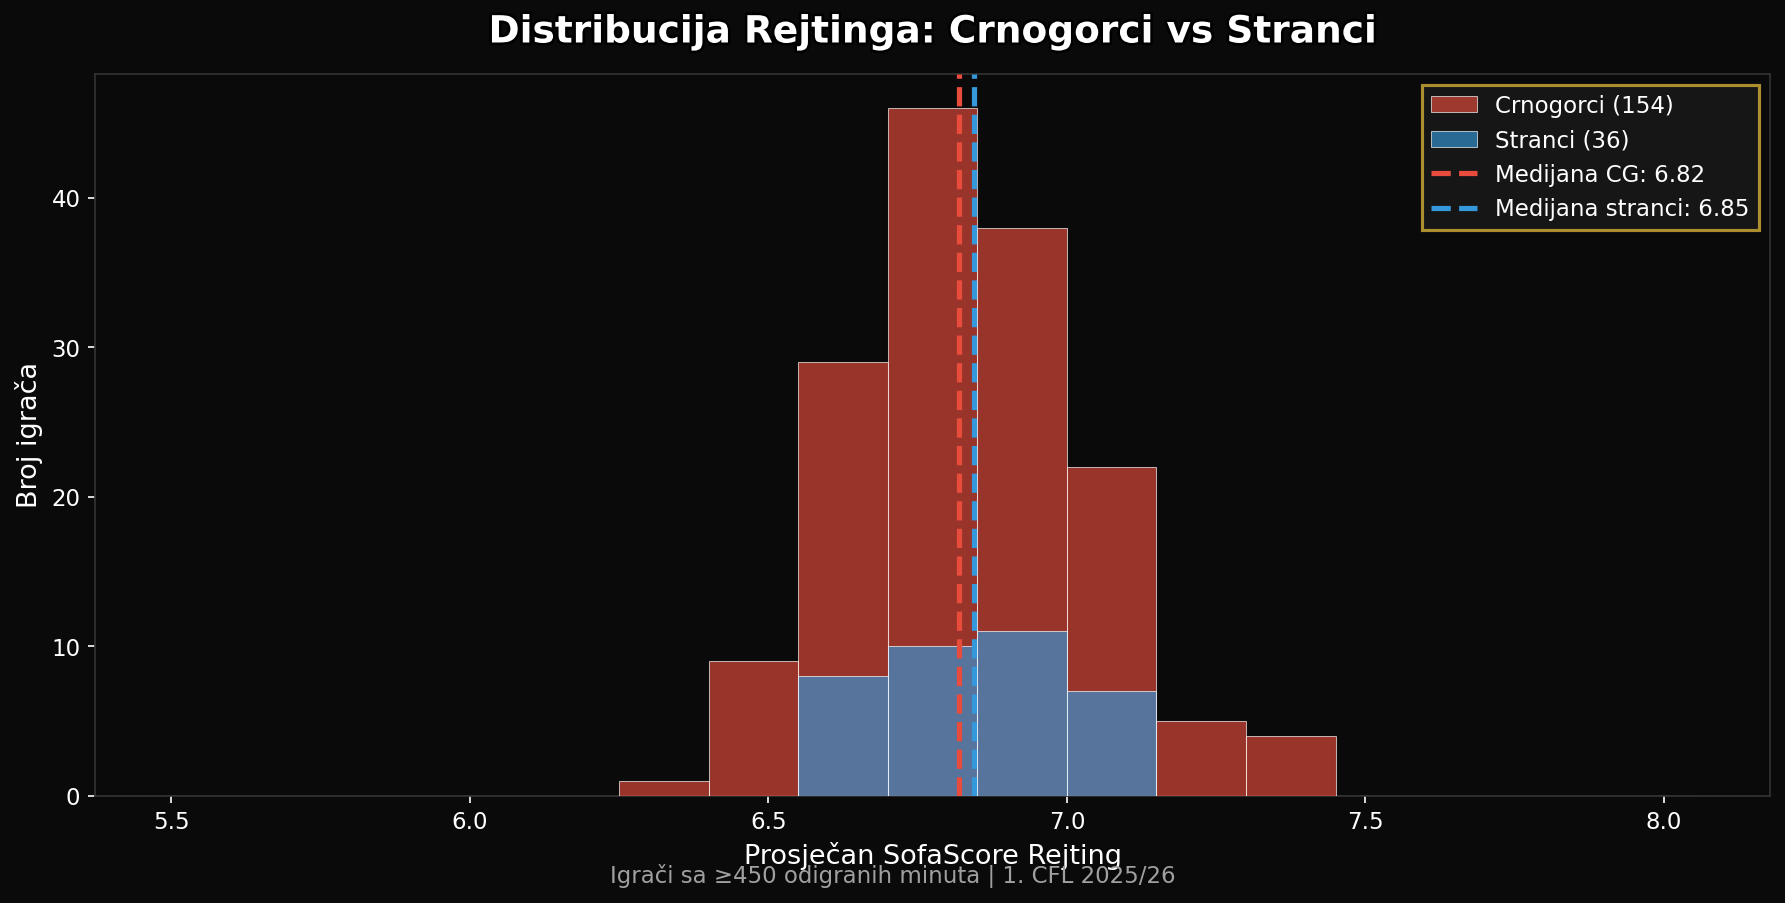

In [34]:
# ─── Figure 1: Distribution Comparison ──────────────────────
fig, ax = plt.subplots(figsize=(12, 6), dpi=150)
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)

bins = np.arange(5.5, 8.1, 0.15)

ax.hist(mne['avg_rating'], bins=bins, alpha=0.65, color=MNE_COLOR, 
        edgecolor='white', linewidth=0.5, label=f'Crnogorci ({len(mne)})', zorder=3)
ax.hist(foreign['avg_rating'], bins=bins, alpha=0.65, color=FOR_COLOR, 
        edgecolor='white', linewidth=0.5, label=f'Stranci ({len(foreign)})', zorder=3)

# Median lines
med_mne = mne['avg_rating'].median()
med_for = foreign['avg_rating'].median()
ax.axvline(med_mne, color=MNE_COLOR, linewidth=2.5, linestyle='--', zorder=4,
           label=f'Medijana CG: {med_mne:.2f}')
ax.axvline(med_for, color=FOR_COLOR, linewidth=2.5, linestyle='--', zorder=4,
           label=f'Medijana stranci: {med_for:.2f}')

ax.set_xlabel('Prosječan SofaScore Rejting', fontsize=13, color=TEXT_WHITE)
ax.set_ylabel('Broj igrača', fontsize=13, color=TEXT_WHITE)
ax.tick_params(colors=TEXT_WHITE, labelsize=11)
for spine in ax.spines.values():
    spine.set_color('#333333')

legend = ax.legend(fontsize=11, fancybox=False, edgecolor=GOLD, 
                   facecolor='#1a1a1a', labelcolor=TEXT_WHITE)
legend.get_frame().set_linewidth(1.5)

title = ax.set_title('Distribucija Rejtinga: Crnogorci vs Stranci',
                     fontsize=18, fontweight='bold', color=TEXT_WHITE, pad=15)
title.set_path_effects([path_effects.Stroke(linewidth=2.5, foreground='black'),
                        path_effects.Normal()])

fig.text(0.5, 0.01, f'Igrači sa ≥{MIN_MINUTES} odigranih minuta | 1. CFL 2025/26',
         fontsize=11, color=TEXT_GREY, ha='center')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'rating_distribution_mne_vs_foreign.png', dpi=300, 
            facecolor=BG_COLOR, bbox_inches='tight')
print('✅ Saved: rating_distribution_mne_vs_foreign.png')
plt.show()

✅ Saved: rating_by_position_mne_vs_foreign.png


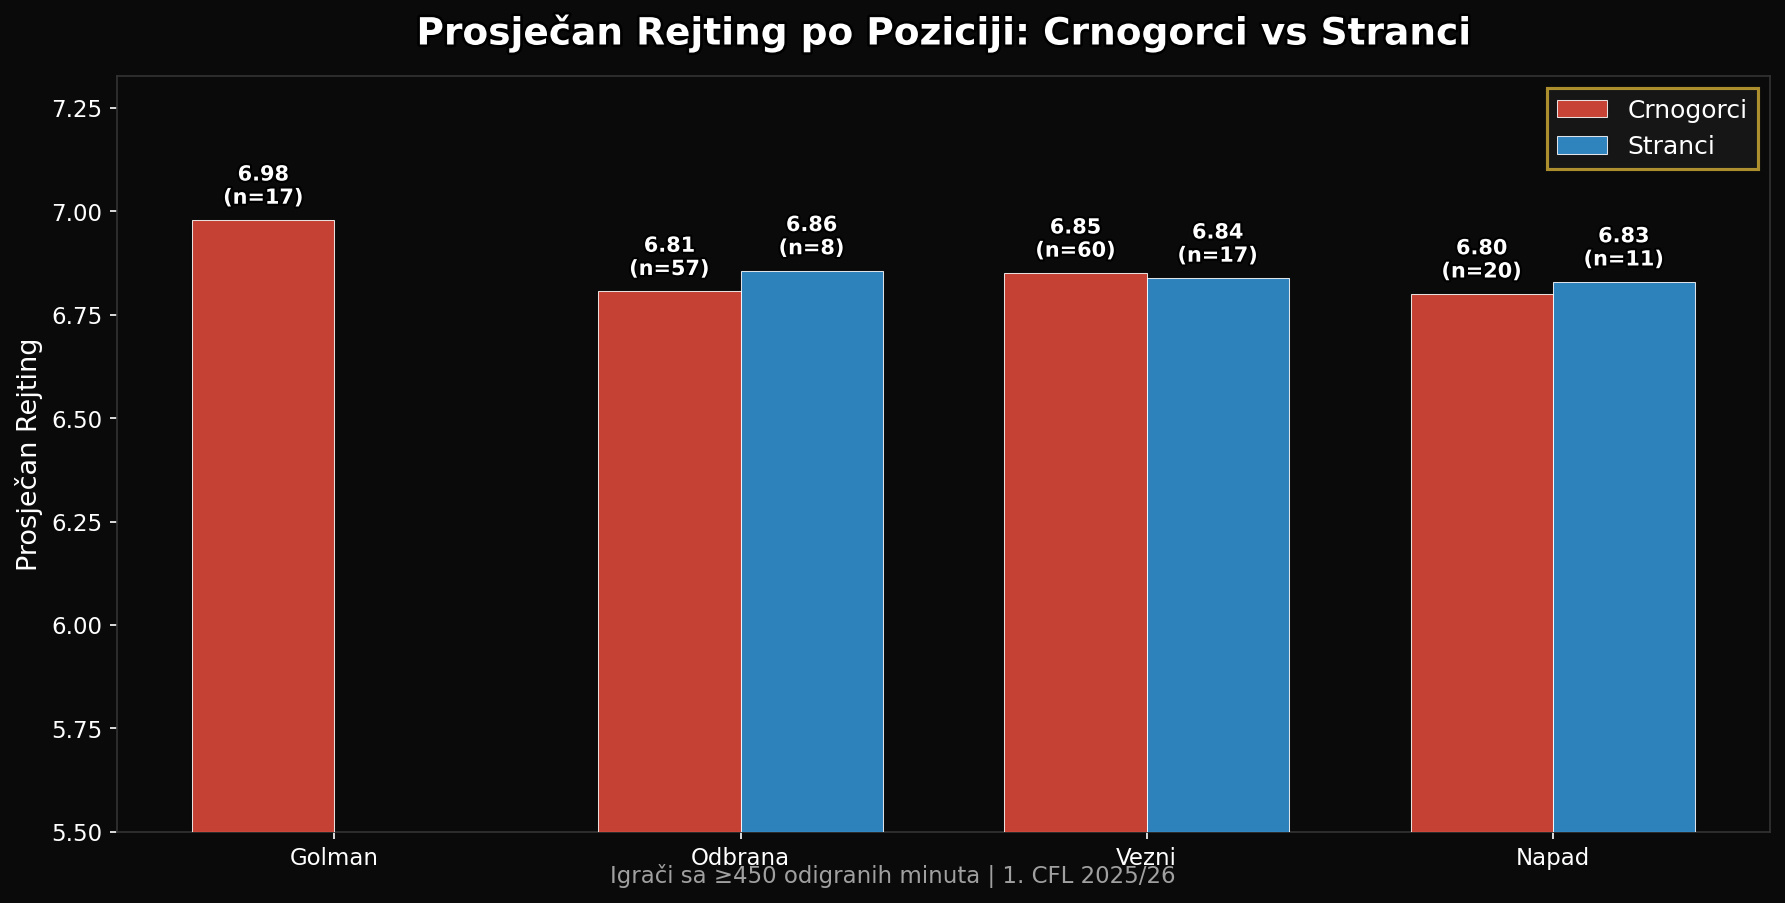

In [35]:
# ─── Figure 2: Average Rating by Position ───────────────────
position_order = ['G', 'D', 'M', 'F']
position_labels = {'G': 'Golman', 'D': 'Odbrana', 'M': 'Vezni', 'F': 'Napad'}

fig, ax = plt.subplots(figsize=(12, 6), dpi=150)
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)

pos_data = []
for pos in position_order:
    m = mne[mne['position'] == pos]['avg_rating']
    f = foreign[foreign['position'] == pos]['avg_rating']
    pos_data.append({
        'position': position_labels[pos],
        'mne_mean': m.mean() if len(m) > 0 else 0,
        'for_mean': f.mean() if len(f) > 0 else 0,
        'mne_n': len(m),
        'for_n': len(f),
    })

x = np.arange(len(position_order))
width = 0.35

bars1 = ax.bar(x - width/2, [d['mne_mean'] for d in pos_data], width, 
               color=MNE_COLOR, alpha=0.85, label='Crnogorci', edgecolor='white', linewidth=0.5, zorder=3)
bars2 = ax.bar(x + width/2, [d['for_mean'] for d in pos_data], width, 
               color=FOR_COLOR, alpha=0.85, label='Stranci', edgecolor='white', linewidth=0.5, zorder=3)

# Value labels
for bar, d in zip(bars1, pos_data):
    if d['mne_mean'] > 0:
        t = ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
                    f'{d["mne_mean"]:.2f}\n(n={d["mne_n"]})', ha='center', va='bottom',
                    fontsize=10, fontweight='bold', color=TEXT_WHITE)
        t.set_path_effects([path_effects.Stroke(linewidth=2, foreground='black'), path_effects.Normal()])

for bar, d in zip(bars2, pos_data):
    if d['for_mean'] > 0:
        t = ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
                    f'{d["for_mean"]:.2f}\n(n={d["for_n"]})', ha='center', va='bottom',
                    fontsize=10, fontweight='bold', color=TEXT_WHITE)
        t.set_path_effects([path_effects.Stroke(linewidth=2, foreground='black'), path_effects.Normal()])

ax.set_xticks(x)
ax.set_xticklabels([d['position'] for d in pos_data], fontsize=13, color=TEXT_WHITE)
ax.set_ylabel('Prosječan Rejting', fontsize=13, color=TEXT_WHITE)
ax.tick_params(colors=TEXT_WHITE, labelsize=11)
ax.set_ylim(bottom=5.5)
for spine in ax.spines.values():
    spine.set_color('#333333')

legend = ax.legend(fontsize=12, fancybox=False, edgecolor=GOLD, 
                   facecolor='#1a1a1a', labelcolor=TEXT_WHITE)
legend.get_frame().set_linewidth(1.5)

title = ax.set_title('Prosječan Rejting po Poziciji: Crnogorci vs Stranci',
                     fontsize=18, fontweight='bold', color=TEXT_WHITE, pad=15)
title.set_path_effects([path_effects.Stroke(linewidth=2.5, foreground='black'),
                        path_effects.Normal()])

fig.text(0.5, 0.01, f'Igrači sa ≥{MIN_MINUTES} odigranih minuta | 1. CFL 2025/26',
         fontsize=11, color=TEXT_GREY, ha='center')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'rating_by_position_mne_vs_foreign.png', dpi=300, 
            facecolor=BG_COLOR, bbox_inches='tight')
print('✅ Saved: rating_by_position_mne_vs_foreign.png')
plt.show()

✅ Saved: top_rated_players_mne_vs_foreign.png


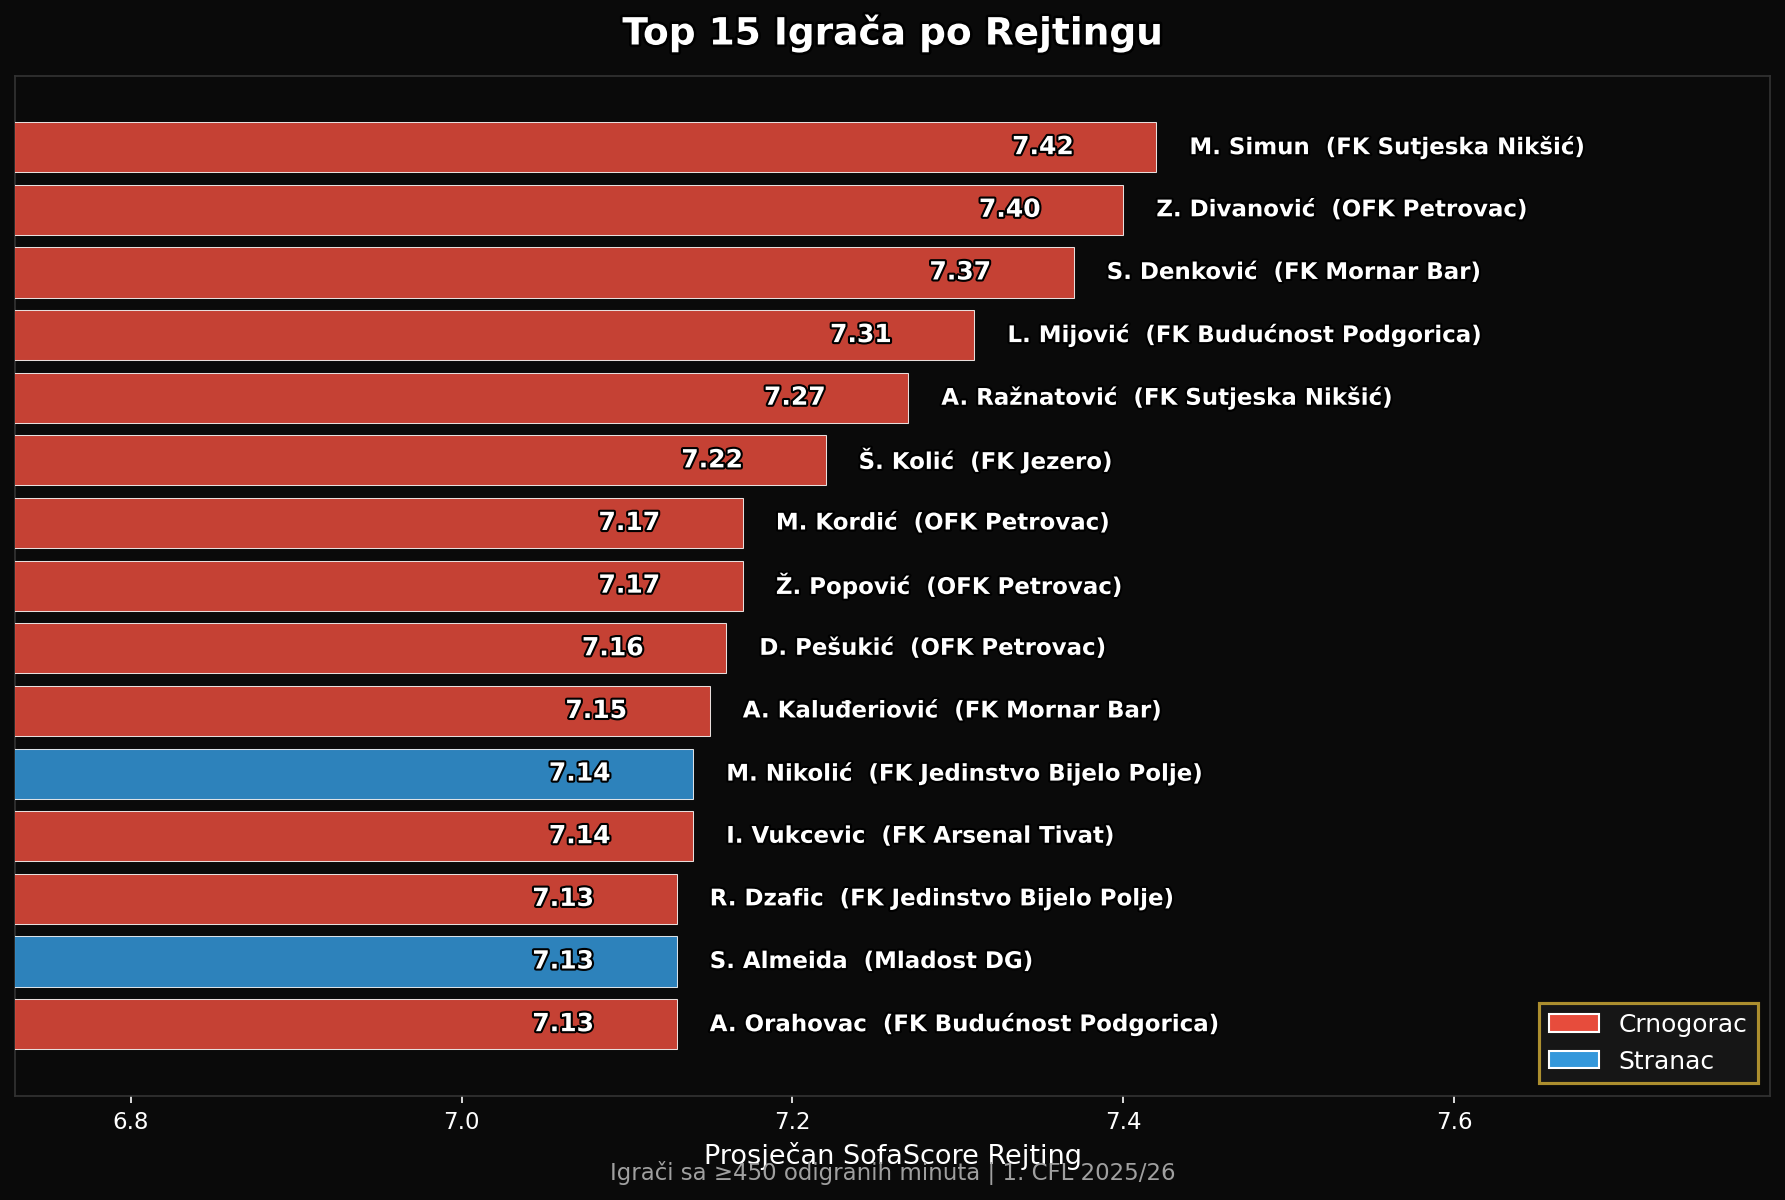

In [36]:
# ─── Figure 3: Top 10 Rated Players (colored by nationality) ─
top = df.nlargest(15, 'avg_rating').copy()

fig, ax = plt.subplots(figsize=(12, 8), dpi=150)
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)

colors = [MNE_COLOR if m else FOR_COLOR for m in top['is_mne']]
bars = ax.barh(range(len(top)), top['avg_rating'], color=colors, 
               edgecolor='white', linewidth=0.5, alpha=0.85, zorder=3)

# Labels
for i, (_, row) in enumerate(top.iterrows()):
    flag = '🇲🇪' if row['is_mne'] else ''
    label = f"{row['shortName']}  ({row['team_name']})"
    t = ax.text(row['avg_rating'] + 0.02, i, label, va='center', fontsize=11,
                color=TEXT_WHITE, fontweight='bold')
    t.set_path_effects([path_effects.Stroke(linewidth=2, foreground='black'), path_effects.Normal()])
    
    # Rating value at end of bar
    t2 = ax.text(row['avg_rating'] - 0.05, i, f'{row["avg_rating"]:.2f}', 
                 va='center', ha='right', fontsize=12, fontweight='bold', color=TEXT_WHITE)
    t2.set_path_effects([path_effects.Stroke(linewidth=2, foreground='black'), path_effects.Normal()])

ax.set_yticks([])
ax.invert_yaxis()
ax.set_xlabel('Prosječan SofaScore Rejting', fontsize=13, color=TEXT_WHITE)
ax.tick_params(colors=TEXT_WHITE, labelsize=11)
ax.set_xlim(left=df['avg_rating'].quantile(0.3))
for spine in ax.spines.values():
    spine.set_color('#333333')

# Legend
legend_elements = [
    mpatches.Patch(facecolor=MNE_COLOR, edgecolor='white', label='Crnogorac'),
    mpatches.Patch(facecolor=FOR_COLOR, edgecolor='white', label='Stranac'),
]
legend = ax.legend(handles=legend_elements, fontsize=12, fancybox=False, 
                   edgecolor=GOLD, facecolor='#1a1a1a', labelcolor=TEXT_WHITE, loc='lower right')
legend.get_frame().set_linewidth(1.5)

title = ax.set_title('Top 15 Igrača po Rejtingu',
                     fontsize=18, fontweight='bold', color=TEXT_WHITE, pad=15)
title.set_path_effects([path_effects.Stroke(linewidth=2.5, foreground='black'),
                        path_effects.Normal()])

fig.text(0.5, 0.01, f'Igrači sa ≥{MIN_MINUTES} odigranih minuta | 1. CFL 2025/26',
         fontsize=11, color=TEXT_GREY, ha='center')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'top_rated_players_mne_vs_foreign.png', dpi=300, 
            facecolor=BG_COLOR, bbox_inches='tight')
print('✅ Saved: top_rated_players_mne_vs_foreign.png')
plt.show()

Players with market value + enough minutes: 176
Market value range: €23,000 – €740,000
Age range: 17 – 39
✅ Saved: market_value_vs_rating.png (1080×1350px)


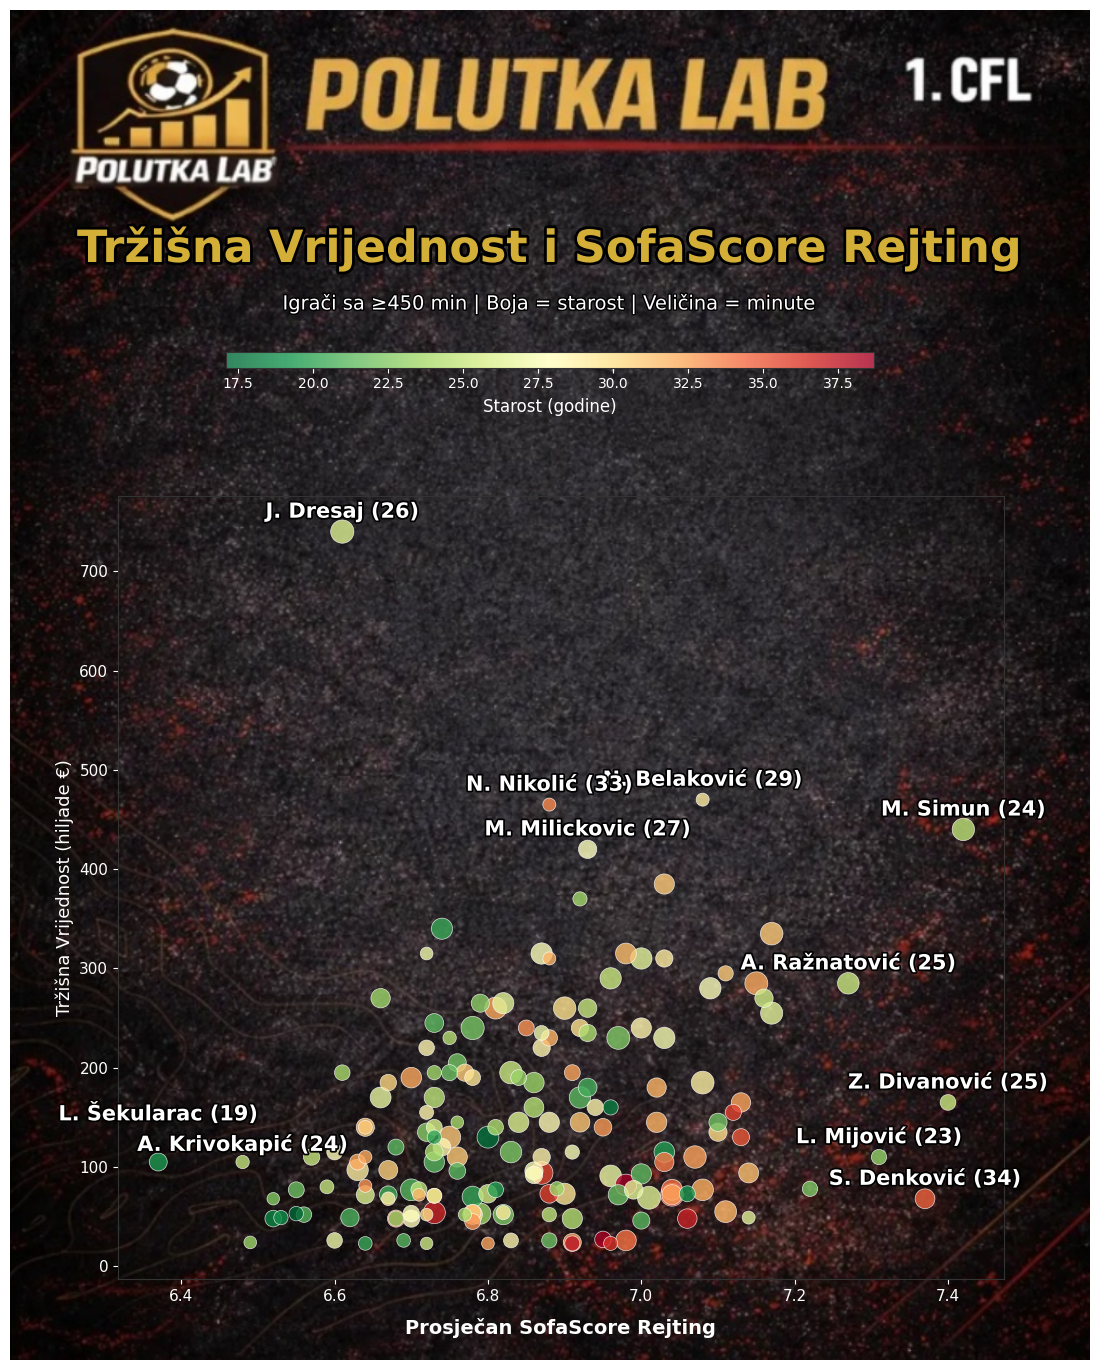

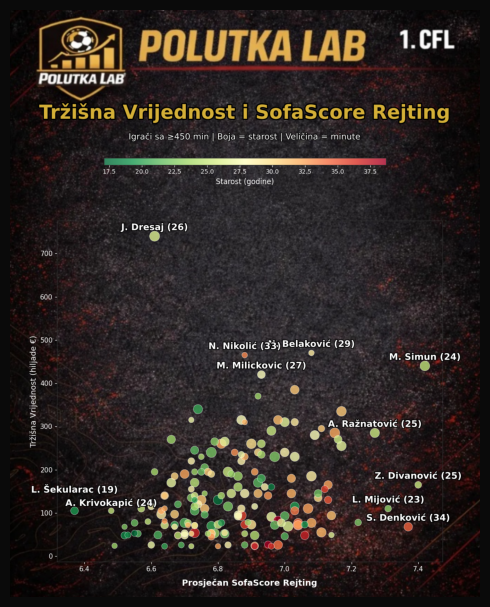

In [43]:
# ─── Figure 4: Market Value vs Average Rating (colored by age) ─
# Merge market value from players_metadata (dateOfBirth already in df from season stats)
mv = players[['id', 'marketValue']].rename(columns={'id': 'player_id'})
df_mv = df.merge(mv, on='player_id', how='left')
df_mv = df_mv[df_mv['marketValue'].notna() & (df_mv['marketValue'] > 0)].copy()
df_mv['mv_k'] = df_mv['marketValue'] / 1000  # in thousands €

# Calculate age
df_mv['dob'] = pd.to_datetime(df_mv['dateOfBirth'], errors='coerce')
df_mv['age'] = ((pd.Timestamp('2026-03-01') - df_mv['dob']).dt.days / 365.25).round(1)

print(f'Players with market value + enough minutes: {len(df_mv)}')
print(f'Market value range: €{df_mv["marketValue"].min():,.0f} – €{df_mv["marketValue"].max():,.0f}')
print(f'Age range: {df_mv["age"].min():.0f} – {df_mv["age"].max():.0f}')

# ─── Instagram post with background.png ─────────────────────
INSTAGRAM_SIZE = (1080, 1350)
BKG_PATH = Path('..') / 'assets' / 'background.png'

background = Image.open(BKG_PATH)
if background.size != INSTAGRAM_SIZE:
    background = background.resize(INSTAGRAM_SIZE, Image.Resampling.LANCZOS)
background_array = np.array(background)

fig = plt.figure(figsize=(10.8, 13.5), dpi=100)

# Background
ax_bg = fig.add_axes([0, 0, 1, 1], zorder=0)
ax_bg.imshow(background_array, aspect='auto', extent=[0, 1, 0, 1])
ax_bg.axis('off')

# Scatter plot axes
ax = fig.add_axes([0.10, 0.06, 0.82, 0.58])
ax.set_facecolor('none')

# Scale dot size by minutes played
size_scale = (df_mv['minutes_played'] / df_mv['minutes_played'].max()) * 250 + 30

# Color by age using a colormap
import matplotlib.cm as cm
import matplotlib.colors as mcolors

age_min, age_max = df_mv['age'].min(), df_mv['age'].max()
norm = mcolors.Normalize(vmin=age_min, vmax=age_max)
cmap = cm.RdYlGn_r  # green = young, red = old

sc = ax.scatter(df_mv['avg_rating'], df_mv['mv_k'], s=size_scale,
                c=df_mv['age'], cmap=cmap, norm=norm, alpha=0.8,
                edgecolors='white', linewidth=0.5, zorder=3)

# Horizontal colorbar at the top, just below subtitle text
cbar_ax = fig.add_axes([0.20, 0.735, 0.60, 0.012])
cbar = fig.colorbar(sc, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Starost (godine)', fontsize=12, color=TEXT_WHITE, labelpad=5)
cbar.ax.tick_params(colors=TEXT_WHITE, labelsize=10)
cbar.outline.set_edgecolor('#333333')

# Label notable players (top market value + top/bottom rating)
top_mv = df_mv.nlargest(5, 'marketValue')
top_rated = df_mv.nlargest(5, 'avg_rating')
bottom_rated = df_mv.nsmallest(2, 'avg_rating')
to_label = pd.concat([top_mv, top_rated, bottom_rated]).drop_duplicates('player_id')

# Hardcoded vertical offsets for overlapping bottom-left players
custom_offsets = {
    'L. Šekularac': (0, 30),
    'A. Krivokapić': (0, 8),
}

for _, row in to_label.iterrows():
    name = row['shortName']
    
    if name in custom_offsets:
        ox, oy = custom_offsets[name]
    else:
        ox, oy = 0, 10
    
    ax.annotate(
        f'{name} ({int(row["age"])})',
        xy=(row['avg_rating'], row['mv_k']),
        xytext=(ox, oy), textcoords='offset points',
        fontsize=15, fontweight='bold', color=TEXT_WHITE, ha='center', zorder=6,
        path_effects=[path_effects.Stroke(linewidth=2.5, foreground='black'), path_effects.Normal()],
    )

ax.set_xlabel('Prosječan SofaScore Rejting', fontsize=14, color=TEXT_WHITE,
              fontweight='bold', labelpad=10)
ax.set_ylabel('Tržišna Vrijednost (hiljade €)', fontsize=13, color=TEXT_WHITE)
ax.tick_params(colors=TEXT_WHITE, labelsize=11)
for spine in ax.spines.values():
    spine.set_color('#333333')

# Title on the background
t1 = ax_bg.text(0.5, 0.84, 'Tržišna Vrijednost i SofaScore Rejting',
                transform=fig.transFigure, fontsize=32, fontweight='bold',
                color=GOLD, ha='center', va='top')
t1.set_path_effects([path_effects.Stroke(linewidth=4, foreground='black'),
                     path_effects.Normal()])

t2 = ax_bg.text(0.5, 0.79, f'Igrači sa ≥{MIN_MINUTES} min | Boja = starost | Veličina = minute',
                transform=fig.transFigure, fontsize=14, color=TEXT_WHITE,
                ha='center', va='top')
t2.set_path_effects([path_effects.Stroke(linewidth=2, foreground='black'),
                     path_effects.Normal()])

# Save to final_posts
slide_path = FINAL_DIR / 'market_value_vs_rating.png'
fig.savefig(slide_path, dpi=100, format='png')
fig.savefig(FIGURES_DIR / 'market_value_vs_rating.png', dpi=100, format='png')

img = Image.open(slide_path)
w, h = img.size
print(f'✅ Saved: {slide_path.name} ({w}×{h}px)')

# Preview
fig_p, ax_p = plt.subplots(figsize=(5, 6.25))
ax_p.imshow(img)
ax_p.axis('off')
fig_p.patch.set_facecolor(BG_COLOR)
plt.tight_layout()
plt.show()